In [1]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "./data"
records = sorted({ os.path.splitext(f)[0] for f in os.listdir(DATA_DIR) if f.endswith('.hea')})
print(f"Found {len(records)} records (hea files):")
print(records[:50])

Found 48 records (hea files):
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [2]:
record_name = records[0]   # change index if you want other file
rec_path = os.path.join(DATA_DIR, record_name)
print("Reading:", rec_path)

record = wfdb.rdrecord(rec_path)
print("Signals shape:", record.p_signal.shape)
print("Signal names:", record.sig_name)
print("Sampling frequency (Hz):", record.fs)


Reading: ./data/100
Signals shape: (650000, 2)
Signal names: ['MLII', 'V5']
Sampling frequency (Hz): 360


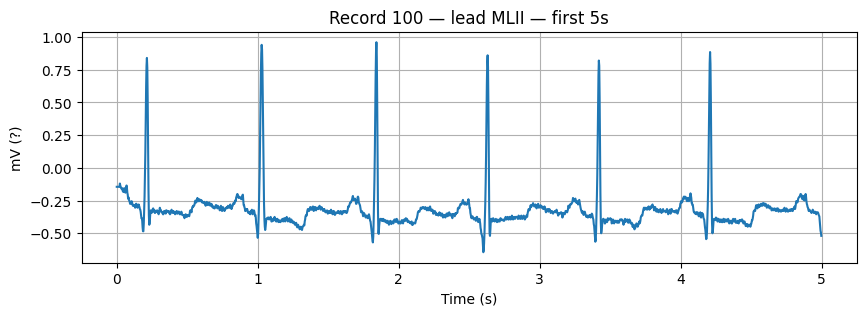

In [3]:
sig = record.p_signal[:,0]   # usually MLII or lead 0
fs = record.fs
t = np.arange(len(sig)) / fs

# plot first 5 seconds
end_s = 5
n = int(end_s * fs)
plt.figure(figsize=(10,3))
plt.plot(t[:n], sig[:n])
plt.title(f"Record {record_name} — lead {record.sig_name[0]} — first {end_s}s")
plt.xlabel("Time (s)"); plt.ylabel("mV (?)")
plt.grid(True)
plt.show()

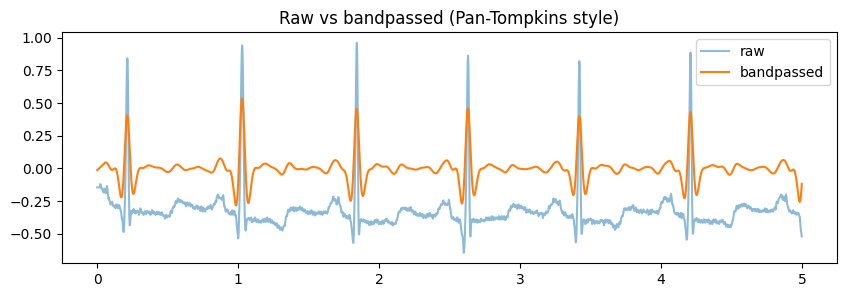

In [4]:
from scipy import signal

def pan_bandpass(sig, fs, low=5.0, high=15.0, order=2):
    nyq = fs/2
    b,a = signal.butter(order, [low/nyq, high/nyq], btype='bandpass')
    return signal.filtfilt(b,a,sig)

sig_clean = pan_bandpass(sig, fs, low=5.0, high=15.0)
plt.figure(figsize=(10,3))
plt.plot(t[:n], sig[:n], label='raw', alpha=0.5)
plt.plot(t[:n], sig_clean[:n], label='bandpassed')
plt.legend()
plt.title("Raw vs bandpassed (Pan-Tompkins style)")
plt.show()


In [6]:
import numpy as np
outpath = f"./cleaned_ecg/{record_name}_clean.csv"
np.savetxt(outpath, sig_clean, fmt="%.6f")
print("Saved cleaned signal to", outpath)

Saved cleaned signal to ./cleaned_ecg/100_clean.csv


1 record (No. 100) was filtered and observed. After the bandpass output is found to be correct, we will now batch‑process all 48 MIT‑BIH ECG records and save it in cleaend_ecg for pan-tompkins computation.

In [7]:
import os
import wfdb
import numpy as np
from scipy import signal

CLEAN_DIR = "./cleaned_ecg"
os.makedirs(CLEAN_DIR, exist_ok=True)

# Band-pass filter function
def pan_bandpass(sig, fs, low=5.0, high=15.0, order=2):
    nyq = fs/2
    b,a = signal.butter(order, [low/nyq, high/nyq], btype='bandpass')
    return signal.filtfilt(b,a,sig)

# Process each record
for rec in records:
    rec_path = os.path.join(DATA_DIR, rec)
    
    # Load ECG
    try:
        record = wfdb.rdrecord(rec_path)
    except:
        print("Skipping invalid record:", rec)
        continue
    
    sig = record.p_signal[:, 0]     # Lead 0 (MLII)
    fs = record.fs
    
    # Clean signal using bandpass
    sig_clean = pan_bandpass(sig, fs)
    
    # Save to cleaned folder
    out_csv = os.path.join(CLEAN_DIR, f"{rec}_clean.csv")
    np.savetxt(out_csv, sig_clean, fmt="%.6f")
    
    print(f"✓ Cleaned {rec} → saved to {out_csv}")

print("\n DONE! All records cleaned and saved.")


✓ Cleaned 100 → saved to ./cleaned_ecg/100_clean.csv
✓ Cleaned 101 → saved to ./cleaned_ecg/101_clean.csv
✓ Cleaned 102 → saved to ./cleaned_ecg/102_clean.csv
✓ Cleaned 103 → saved to ./cleaned_ecg/103_clean.csv
✓ Cleaned 104 → saved to ./cleaned_ecg/104_clean.csv
✓ Cleaned 105 → saved to ./cleaned_ecg/105_clean.csv
✓ Cleaned 106 → saved to ./cleaned_ecg/106_clean.csv
✓ Cleaned 107 → saved to ./cleaned_ecg/107_clean.csv
✓ Cleaned 108 → saved to ./cleaned_ecg/108_clean.csv
✓ Cleaned 109 → saved to ./cleaned_ecg/109_clean.csv
✓ Cleaned 111 → saved to ./cleaned_ecg/111_clean.csv
✓ Cleaned 112 → saved to ./cleaned_ecg/112_clean.csv
✓ Cleaned 113 → saved to ./cleaned_ecg/113_clean.csv
✓ Cleaned 114 → saved to ./cleaned_ecg/114_clean.csv
✓ Cleaned 115 → saved to ./cleaned_ecg/115_clean.csv
✓ Cleaned 116 → saved to ./cleaned_ecg/116_clean.csv
✓ Cleaned 117 → saved to ./cleaned_ecg/117_clean.csv
✓ Cleaned 118 → saved to ./cleaned_ecg/118_clean.csv
✓ Cleaned 119 → saved to ./cleaned_ecg/119_cle

To visualize the raw data with the bandpassed data, use this code and change the record number and lead number (0 is MLII, 1 is V1/V2..) accordingly.

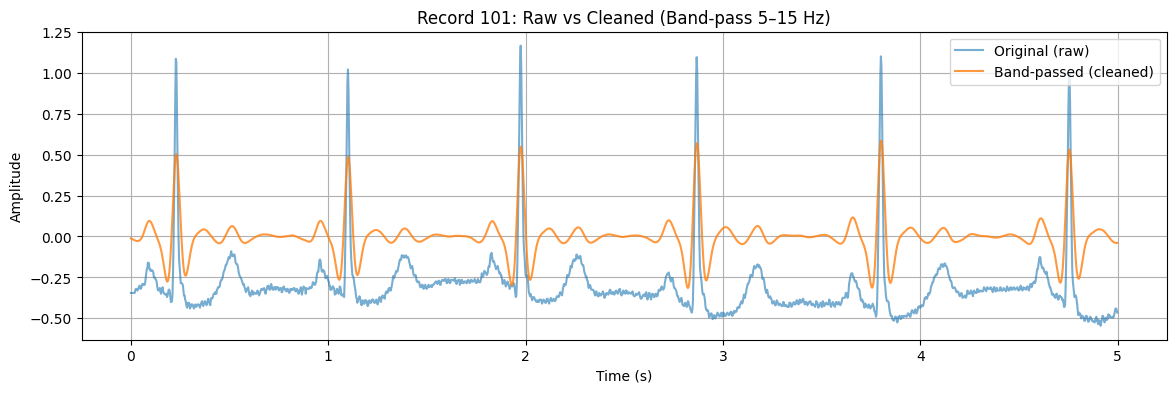

In [8]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt

record_name = "101"   # change to any record: 100, 101, ... 234

# Load RAW ECG
rec_path = os.path.join(DATA_DIR, record_name)
record = wfdb.rdrecord(rec_path)
raw = record.p_signal[:, 0]   # lead 0 (MLII)
fs = record.fs
t = np.arange(len(raw)) / fs

# Load CLEANED ECG
clean_path = os.path.join(CLEAN_DIR, f"{record_name}_clean.csv")
clean = np.loadtxt(clean_path)

# Plot 0–5 seconds for clarity
end_s = 5
n = int(end_s * fs)

plt.figure(figsize=(14,4))
plt.plot(t[:n], raw[:n], label="Original (raw)", alpha=0.6)
plt.plot(t[:n], clean[:n], label="Band‑passed (cleaned)", alpha=0.8)
plt.title(f"Record {record_name}: Raw vs Cleaned (Band‑pass 5–15 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()
